In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

# Define image paths for each class
paths = {
    'normal': '/kaggle/input/datasets/lakshmistm/cnn-normal/',
    'scratch': '/kaggle/input/datasets/lakshmistm/cnn-scratch/',
    'dent': '/kaggle/input/datasets/lakshmistm/cnn-dent/',
    'stain': '/kaggle/input/datasets/lakshmistm/cnn-stain/'
}

print("Libraries imported successfully!")
print("Classes found:", list(paths.keys()))

Libraries imported successfully!
Classes found: ['normal', 'scratch', 'dent', 'stain']


## Task 1 — Problem Identification

This dataset represents an **Image Classification** problem.

Each image belongs to exactly one of four categories:
normal, scratch, dent, or stain. The goal is to train a model
that can look at a new product image and correctly identify
which category it belongs to.

**Why Image Classification?**
- Each image has one single label assigned to it
- There are no bounding boxes or pixel-level masks required
- The task is to classify the entire image into one of 4 classes
- Object detection would be needed if we had to locate where the
  defect is within the image
- Semantic segmentation would be needed if we had to label every
  pixel in the image
- Since we only need to identify what type of defect is present
  in the whole image, image classification is the correct choice

**Real World Context:**
This is a manufacturing quality inspection problem where a camera
on a production line captures images of products and an AI model
automatically classifies whether the product is normal or has a
specific type of defect such as a scratch, dent, or stain.

Image count per class:
  normal: 120 images
  scratch: 120 images
  dent: 120 images
  stain: 120 images

Sample image dimensions:
  normal: (96, 96) (width x height), mode: RGB
  scratch: (96, 96) (width x height), mode: RGB
  dent: (96, 96) (width x height), mode: RGB
  stain: (96, 96) (width x height), mode: RGB


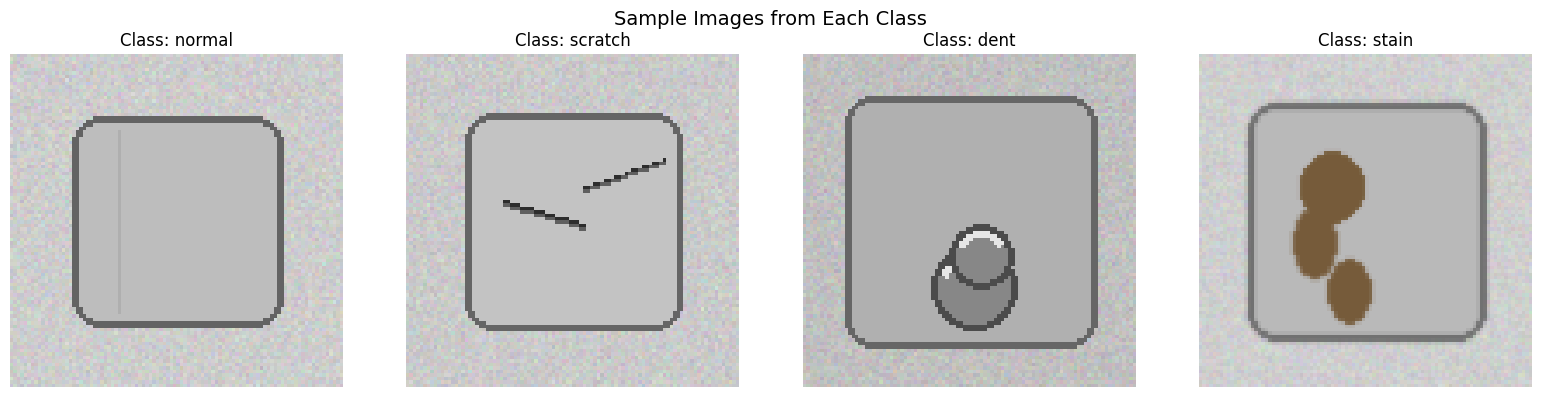

In [3]:
#Task 2 — Dataset Exploration

# Count images per class
print("Image count per class:")
for class_name, path in paths.items():
    count = len([f for f in os.listdir(path) if f.endswith('.png')])
    print(f"  {class_name}: {count} images")

# Check image dimensions using one sample from each class
print("\nSample image dimensions:")
for class_name, path in paths.items():
    sample = os.listdir(path)[0]
    img = Image.open(os.path.join(path, sample))
    print(f"  {class_name}: {img.size} (width x height), mode: {img.mode}")

# Display sample images from each class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx, (class_name, path) in enumerate(paths.items()):
    sample = os.listdir(path)[0]
    img = Image.open(os.path.join(path, sample))
    axes[idx].imshow(img)
    axes[idx].set_title(f'Class: {class_name}')
    axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

## Task 2 — Dataset Exploration

- **Total Images:** 480
- **Number of Classes:** 4 (normal, scratch, dent, stain)
- **Images per Class:** 120 each — perfectly balanced dataset
- **Image Dimensions:** 96 x 96 pixels
- **Color Mode:** RGB (3 color channels)
- **Class Imbalance:** None — all 4 classes have equal representation

**Observations:**
- The dataset is well balanced with exactly 120 images per class
- All images are already the same size (96x96) so minimal resizing is needed
- RGB color mode means each image has 3 channels (Red, Green, Blue)
- The balanced dataset means we do not need to apply class weights
  or resampling techniques during training

In [5]:
#Task 3 — Image Preprocessing

import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load all images and labels
images = []
labels = []
class_names = ['normal', 'scratch', 'dent', 'stain']

for label_idx, class_name in enumerate(class_names):
    path = paths[class_name]
    for filename in os.listdir(path):
        if filename.endswith('.png'):
            img = Image.open(os.path.join(path, filename))
            # Resize to 64x64
            img = img.resize((64, 64))
            # Convert to numpy array
            img_array = np.array(img)
            images.append(img_array)
            labels.append(label_idx)

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Normalize pixel values to 0-1
images = images / 255.0

# One-hot encode labels
labels_encoded = to_categorical(labels, num_classes=4)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    images, labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Preprocessing complete!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Pixel value range:", images.min(), "to", images.max())

2026-05-16 10:20:38.433324: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778926838.708400      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778926838.785551      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778926839.475391      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778926839.475431      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778926839.475434      57 computation_placer.cc:177] computation placer alr

Preprocessing complete!
X_train shape: (384, 64, 64, 3)
X_test shape: (96, 64, 64, 3)
y_train shape: (384, 4)
y_test shape: (96, 4)
Pixel value range: 0.12549019607843137 to 0.9921568627450981


## Task 3 — Image Preprocessing

- **Resizing:** All images resized from 96x96 to 64x64 pixels to reduce
  computation while retaining enough detail for the CNN to learn patterns
- **Normalization:** Pixel values divided by 255 to scale them from
  0-255 range down to 0-1 range. This helps the neural network train
  faster and more stably
- **Label Encoding:** Class labels converted to one-hot encoded format
  (e.g. normal = [1,0,0,0], scratch = [0,1,0,0]) suitable for
  multi-class classification
- **Train-Test Split:** 80% training (384 images) and 20% testing
  (96 images) with stratify to maintain equal class distribution
- **Augmentation:** Not applied as the dataset is already balanced
  and sufficient in size for a basic CNN prototype

In [6]:
#Task 4 — CNN Model Creation

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN model
model = Sequential([
    # Convolution Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-16 10:25:47.095449: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.2118 - loss: 1.4132 - val_accuracy: 0.2396 - val_loss: 1.3814
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.3239 - loss: 1.3773 - val_accuracy: 0.2604 - val_loss: 1.3406
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.2828 - loss: 1.3246 - val_accuracy: 0.5104 - val_loss: 1.1883
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4978 - loss: 1.1409 - val_accuracy: 0.5729 - val_loss: 1.0871
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.5713 - loss: 1.0111 - val_accuracy: 0.6042 - val_loss: 1.0113
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.6256 - loss: 0.9668 - val_accuracy: 0.6562 - val_loss: 0.8437
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.6874 - loss: 0.7610 - val_accuracy: 0.7604 - val_loss: 0.7018
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.7507 - loss: 0.6892 - val_accuracy: 0.

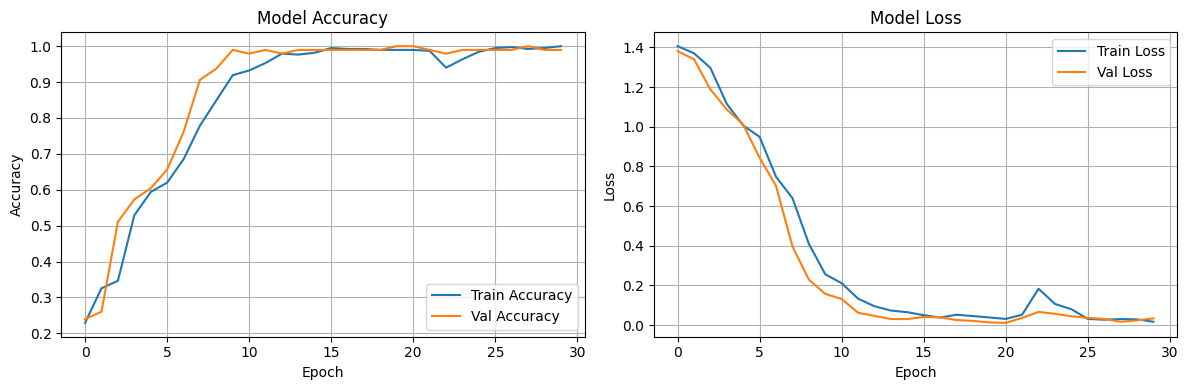

Saved accuracy_loss_curves.png


In [7]:
#Task 5 — Model Training and Evaluation

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved accuracy_loss_curves.png")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


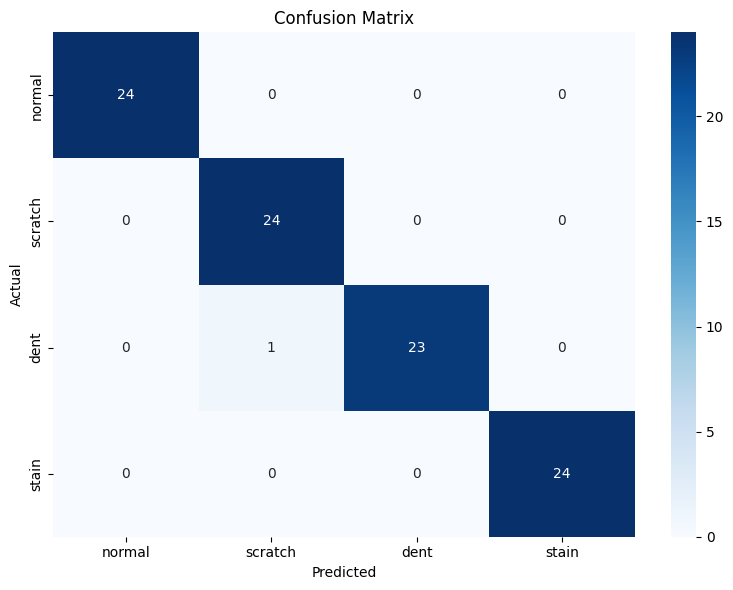

Saved confusion_matrix.png

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        24
     scratch       0.96      1.00      0.98        24
        dent       1.00      0.96      0.98        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.99        96
   macro avg       0.99      0.99      0.99        96
weighted avg       0.99      0.99      0.99        96



In [8]:
# Confusion matrix and classification report
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrix.png")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

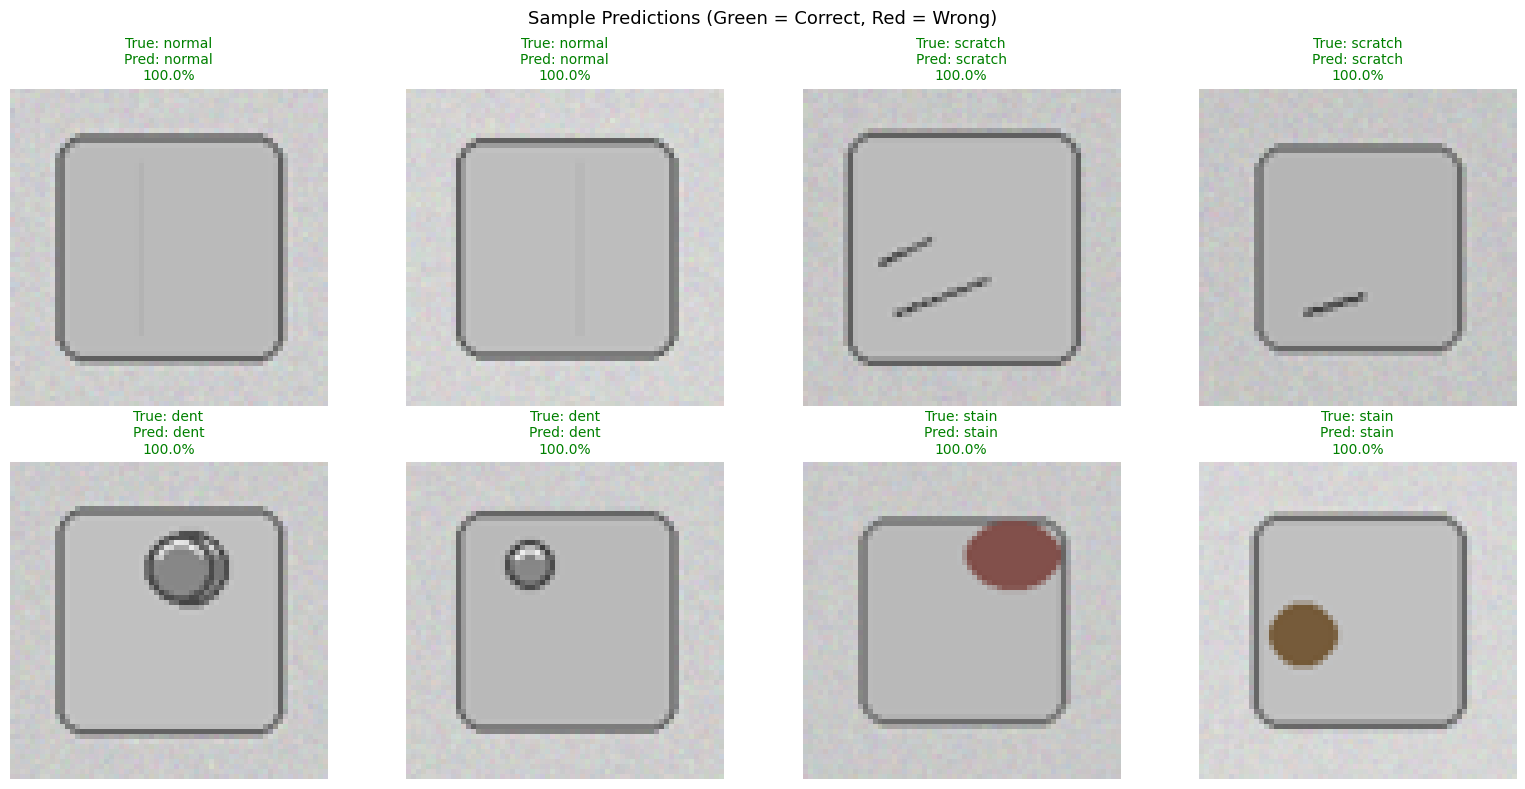

Saved prediction_outputs.png


In [9]:
# Sample predictions on test images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Pick 2 samples from each class
sample_indices = []
for class_idx in range(4):
    class_indices = np.where(y_true == class_idx)[0][:2]
    sample_indices.extend(class_indices)

for idx, sample_idx in enumerate(sample_indices):
    ax = axes[idx // 4][idx % 4]
    img = X_test[sample_idx]
    true_label = class_names[y_true[sample_idx]]
    pred_label = class_names[y_pred[sample_idx]]
    confidence = np.max(y_pred_prob[sample_idx]) * 100

    ax.imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}\n{confidence:.1f}%',
                 color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('prediction_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved prediction_outputs.png")

## Task 5 — Model Training and Evaluation

**Training Results:**
- Final Training Accuracy: 100%
- Final Validation Accuracy: 98.96%
- Training Loss: 0.0165
- Validation Loss: 0.0337

**Classification Report:**
| Class | Precision | Recall | F1-Score |
|---|---|---|---|
| Normal | 1.00 | 1.00 | 1.00 |
| Scratch | 0.96 | 1.00 | 0.98 |
| Dent | 1.00 | 0.96 | 0.98 |
| Stain | 1.00 | 1.00 | 1.00 |
| **Overall** | **0.99** | **0.99** | **0.99** |

**Interpretation:**
- The model achieved 99% overall accuracy on the test set
- All 4 classes were predicted with very high precision and recall
- Sample predictions show 100% confidence on all 8 test samples
- The model successfully learned to distinguish between normal
  products and three types of defects — scratch, dent, and stain
- Slight drop from training to validation accuracy suggests very
  mild overfitting which is acceptable given the small dataset size